# Engine and Optimizations

## Overview ##

This notebook presents a simple way to use the graph_rewrite library for optimizing query execution. We would use spannerlog to write the queries and generate their execution graphs, and a modified version of spannerlib's engine defined in this notebook to run the execution graphs, while profiling the query runtime metrics.

## Imports

In [1]:
import pandas as pd
pd.set_option("mode.copy_on_write", True)
import numpy as np
from typing import no_type_check, Set, Sequence, Any,Optional,List,Callable,Dict,Union
import networkx as nx
import itertools
from collections import defaultdict
import sys
import os
from pathlib import Path
#import seaborn as sns
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
sys.path.append("../../spannerlib/spannerlib")

import time


from spannerlib.span import Span
from spannerlib.data_types import (
    Var, 
    FreeVar, 
    RelationDefinition, 
    Relation, 
    IEFunction,
    AGGFunction,
    IERelation, 
    Rule, 
    pretty
)
from spannerlib.ra import (
    _col_names,
    get_const,
    select,
    project,
    rename,
    union,
    intersection,
    difference,
    join,
    product,
    groupby,
    ie_map,
    merge_rows
)

from spannerlib.term_graph import graph_compose, merge_term_graphs_pair,rule_to_graph,add_relation,add_project_uniq_free_vars
from spannerlib.engine import Engine, IEFunction, AGGFunction
from spannerlib import get_magic_session,Span


from graph_rewrite import draw
from graph_rewrite import rewrite, rewrite_iter


import logging
logger = logging.getLogger(__name__)

## Utils ##

Define the engine (compute_node func) and its dependencies.

The engine is a simplified version of the Spannerlib engine, designed to operate on trees. It extends the original implementation by integrating profiling capabilities.


In [2]:
def schema_match(schema,expected,ignore_types=None):
    """checks if"""
    if len(schema) != len(expected):
        return False
    if ignore_types is None:
        ignore_types = []
    for x,y in zip(schema,expected):
        if x in ignore_types:
            continue
        if not issubclass(x,y):
            return False
    return True


def is_of_schema(relation,schema,ignore_types=None):
    """checks if a relation is of a given schema"""
    try:
        if len(relation) != len(schema):
            return False
        if ignore_types is None:
            ignore_types = []
        for x,y in zip(relation,schema):
            if type(x) in ignore_types:
                continue
            if not isinstance(x,y):
                return False
        return True
    except Exception as e:
        logger.error(f"Got Error when computing:\n"
                     f"is_of_scehma({relation},{schema})\n"
                     f"Error: {e}")
        raise e

def type_merge(type1,type2):
    if issubclass(type1,type2):
        return type1
    elif issubclass(type2,type1):
        return type2
    else:
        raise ValueError(f"Trying to merge types {type1},{type2}, types are incompatible")

def schema_merge(schema1,schema2):
    """merges two schemas, taking the stricter type between the two for each index"""
    if len(schema1) != len(schema2):
        raise ValueError(f"Trying to merge schemas {schema1},{schema2} schemas must be of the same length")
    
    new_schema = [type_merge(x,y) for x,y in zip(schema1,schema2)]
    return new_schema

In [3]:
import re
STRING_PATTERN = re.compile(r"^[^\r\n]+$")

def isFloat(s):  
   n = '0123456789.' 
   return (all(x in n for x in s) and s.count('.') == 1)  
 
def isInt(s):  
   n = '0123456789'    
   return all(x in n for x in s) 

def _infer_relation_schema(row) -> Sequence[type]: # Inferred type list of the given relation
    """
    Guess the relation type based on the data.
    We support both the actual types (e.g. 'Span'), and their string representation ( e.g. `"[0,8)"`).

    **@raise** ValueError: if there is a cell inside `row` of an illegal type.
    """
    relation_types = []
    for cell in row:
        if not isinstance(cell, str):
            relation_types.append(type(cell))
        elif isInt(cell):
            relation_types.append(int)
        elif isFloat(cell):
            relation_types.append(float)
        elif cell in ['True', 'False']:
            relation_types.append(bool)
        else:
            relation_types.append(str)
        
    return relation_types

In [4]:
class DB(dict):
    def __repr__(self):
        key_str=', '.join(self.keys())
        return f'DB({key_str})'

In [5]:
def _col_names(length):
    # these names wont conflict with logical variables since they must always start with Uppercase letters
    return [f'col_{i}' for i in range(length)]

In [6]:
# some select theta functions

class equalConstTheta():
    def __init__(self,*pos_val_tuples):
        self.pos_val_tuples = pos_val_tuples
    def __call__(self,df):
        masks = [df.iloc[:,pos]==val for pos,val in self.pos_val_tuples]
        return pd.concat(masks,axis=1).all(axis=1)
    def __str__(self):
        return f'''Theta({', '.join([f'col_{pos}={val}' for pos,val in self.pos_val_tuples])})'''
    def __repr__(self):
        return str(self)
    def __eq__(self,other):
        if not isinstance(other,equalConstTheta):
            return False
        return self.pos_val_tuples == other.pos_val_tuples

class equalColTheta():
    def __init__(self,*col_pos_tuples):
        self.col_pos_tuples = col_pos_tuples

    def __call__(self,df):
        masks = [df.iloc[:,pos1]==df.iloc[:,pos2] for pos1,pos2 in self.col_pos_tuples]
        return pd.concat(masks,axis=1).all(axis=1)    
    def __str__(self):
        return f'''Theta({', '.join([f'col_{pos1}=col_{pos2}' for pos1,pos2 in self.col_pos_tuples])})'''
    def __repr__(self):
        return str(self)
    def __eq__(self,other):
        if not isinstance(other,equalColTheta):
            return False
        return self.col_pos_tuples == other.col_pos_tuples

In [7]:
def get_const(const_dict,**kwargs):
    return pd.DataFrame([const_dict])


def is_truthy(df):
    return df.shape==(1,0)

def is_falsy(df):
    return df.shape==(0,0)

## RA ops

In [8]:
def select(df,theta,schema,**kwargs):
    if df is None or df.empty:
        return pd.DataFrame(columns=schema)
    if callable(theta):
        return df[theta(df)]
    else:
        raise ValueError(f"theta must be callable, got {theta}")

def project(df,schema,**kwargs):
    if df is None or df.empty:
        return pd.DataFrame(columns=schema)
    return df[schema]
    
def rename(df,schema,**kwargs):
    if df is None or df.empty:
        return pd.DataFrame(columns=schema)
    
    df=df.copy()
    df.columns = schema
    return df

def intersection(df1,df2,schema,**kwargs):
    if df1 is None or df2 is None or df1.empty or df2.empty:
        return pd.DataFrame(columns=schema)
    return pd.merge(df1,df2,how='inner',on=list(df1.columns))

def difference(df1,df2,schema,**kwargs):
    if df1 is None or df2 is None or df1.empty or df2.empty:
        return pd.DataFrame(columns=schema)
    return pd.concat([df1,df2]).drop_duplicates(keep=False)


def product(df1,df2,schema,**kwargs):
    if df1 is None or df2 is None or df1.empty or df2.empty:
        return pd.DataFrame(columns=schema)
    return pd.merge(df1,df2,how='cross')

def join(df1,df2,schema,**kwargs):
    if df1 is None or df2 is None or is_falsy(df1) or is_falsy(df2):
        return pd.DataFrame(columns=schema)

    # if one of the dataframes is truthy, return the other
    # this solves the problem of joining with a constant
    if is_truthy(df1):
        return df2
    if is_truthy(df2):
        return df1

    cols1 = set(df1.columns)
    cols2 = set(df2.columns)
    on = cols1 & cols2
    # get only logical variables
    # on = [ col for col in on if isinstance(col,str) and col[0].isupper()]
    on = list(on)
    if len(on)==0:
        return pd.merge(df1,df2,how='cross')
    else:
        return pd.merge(df1,df2,how='inner',on=on)
    
def merge_rows(*dfs):
    return pd.DataFrame(
        set.union(*[set(df.itertuples(index=False,name=None)) for df in dfs])
    )


def union(*dfs,schema,**kwargs):
    # use numpy arrays to ignore column names
    non_empty_dfs = []
    for df in dfs:
        if df is not None and not df.empty:
            non_empty_dfs.append(df)
    if len(non_empty_dfs)==0:
        return pd.DataFrame(columns=schema)
    else:
        return rename(merge_rows(*non_empty_dfs),schema)
        # This line didnt work since drop duplicates doesnt work correctly on non primitive classes such as Spans
        # return pd.DataFrame(np.concatenate(non_empty_dfs,axis=0),columns=schema).drop_duplicates(ignore_index=True)
        
def groupby(df,schema,agg,**kwargs):
    if df is None or df.empty:
        return pd.DataFrame(columns=schema)
    
    # rename columns to numbers so that we can aggregate the same free var to multiple places
    uniq_cols_df = rename(df,schema=[i for i in range(len(schema))])

    groupby_cols = [i for i,agg_func in enumerate(agg) if agg_func is None]
    agg_by_cols = {i:agg_func for i,agg_func in enumerate(agg) if agg_func is not None}
    # a real groupby
    if len(groupby_cols)>0:
        return rename(
            project(
                uniq_cols_df.groupby(groupby_cols).agg(agg_by_cols).reset_index(),
                schema = uniq_cols_df.columns
                ),
            schema)
    # no group by vars, so aggs contain all columns and schema simply orders them
    else:

        # this conversion magic is caused by an inconsistency between series and dataframes aggs,
        # to enable using both function and str aliases we
        # we take each column, convert to a frame
        # aggregate it and then squeeze it to a series (which has a single value)
        # then feed that to the dataframe constructor
        return rename(
            pd.DataFrame({
                col:[uniq_cols_df[col].to_frame().agg(agg_by_cols[col]).squeeze()] for col in range(len(agg_by_cols))
            }),
            schema)

In [9]:
def coerce_tuple_like(name,func,input,output):
    if isinstance(output,(tuple,list)):
        return output
    else:
        logger.debug(f"IEFunction {name} with underlying function {func}\n"
                        f"returned a value that is not a tuple/list\n"
                        f"for input {input} -> {output}\n"
                        f"coercing to tuple")
        return (output,)

def assert_ie_schema(name,func,value,expected_schema,arity,input_or_output='input'):
    if callable(expected_schema):
        expected_schema = expected_schema(arity)
    if not is_of_schema(value,expected_schema):
        raise ValueError(
            f"IEFunction {name} with underlying function {func}\n"
            f"received an {input_or_output} value {value}(schema={pretty(_infer_relation_schema(value))})\n"
            f"but expected {pretty(expected_schema)}")

def assert_iterable(name,func,input,output):
    try:
        out_iter = iter(output)
    except TypeError:
        raise ValueError(f"IEFunction {name} with underlying function {func}\n"
                f"returned a value that is not an iterable\n"
                f"for input {input} -> {output}")

# TODO: add issue to spannerlib
def replace_f_with_c(input_string):
    if input_string.startswith("_F"):
        return input_string.replace("_F", "_C", 1)
    return input_string
        
def add_const(row,schema,in_arity,kwargs):
    in_schema = schema[:in_arity]
    new_row = []
    list_row = list(row)
    if 'const_dict' in kwargs:
        const_dict = kwargs['const_dict']
        list_cols = 0
        for col in in_schema:
            col = replace_f_with_c(col)
            if col in const_dict:
                new_row.append(const_dict[col])
            else:
                new_row.append(list_row[list_cols])
                list_cols += 1
        return new_row
    return list_row

# TODO: Try to do the add_const better, maybe product then project
def map_iter(df,name,func,schema,in_schema,out_schema,in_arity,out_arity,**kwargs):
    """helper function returns an iterator that applies a function to each row of a dataframe
    """
    for _,in_row in df.iterrows():
        in_row = add_const(in_row,schema,in_arity,kwargs)
        assert_ie_schema(name,func,in_row,in_schema,in_arity,input_or_output='input')
        output = func(*in_row)
        assert_iterable(name,func,in_row,output)
        for out_row in output:
            out_row = coerce_tuple_like(name,func,in_row,out_row)
            out_row = list(out_row)
            assert_ie_schema(name,func,out_row,out_schema,out_arity,input_or_output='output')
            yield in_row + out_row


def ie_map(df,name,func,schema,in_schema,out_schema,in_arity,out_arity,**kwargs):
    """given an indexed dataframe, apply an ie function to each row and return the output 
    such that each output relation is indexed by the same index as the input relation that generated it
    """
    if df is None or df.empty:
        return pd.DataFrame(columns=_col_names(in_arity+out_arity))
    output_iter = map_iter(df,name,func,schema,in_schema,out_schema,in_arity,out_arity, **kwargs)
    total_arity = in_arity + out_arity
    return pd.DataFrame(output_iter,columns=schema)

## Engine

In [10]:

def get_rel(rel,db,**kwargs):
    # helper function to get the relation from the db for external relations
    return db[rel]

op_to_func = {
    'union':union,
    'intersection':intersection,
    'difference':difference,
    'select':select,
    'project':project,
    'rename':rename,
    'join':join,
    'ie_map':ie_map,
    'get_rel':get_rel,
    'get_const':get_const,
    'product':product,
    'groupby':groupby
}

In [11]:
def calculate_dfs_rows(*dfs):
    if dfs:
        return sum([df.shape[0] for df in dfs])
    return 0

In [12]:
def profile_wrapper(op_func, profile_data, children_results, u_data):
    start = time.time()
    res = op_func(*children_results, **u_data)
    end = time.time()
    profile_data[op_func.__name__]["row_count"] += calculate_dfs_rows(*children_results)
    profile_data[op_func.__name__]["total_time"] += end - start
    return res, end - start

In [13]:
def _collect_children_and_run(G,u,results,profile_data,stack,log=False):
    children = list(G.successors(u))
    u_data = G.nodes[u]

    children_results = [results[v][-1] for v in children]
    op_func = op_to_func[u_data['op']]

    if log:
        logger.debug(f"computing node {u} with children {children} and data {u_data} , stack = {stack}")
        logger.debug(f"children results are {children_results}")
        logger.debug(f"children_data is {[G.nodes[v] for v in children]}")
    try:
        res, op_time = profile_wrapper(op_func, profile_data, children_results, u_data)
    except Exception as e:
        raise Exception(f'During excution of node {u} with args {children_results} and kwargs {u_data}'
                        f' got error {e}'
        )
    if log:
        logger.debug(f"result of node {u} is {res}")
    results[u].append(res)
    G.nodes[u]['op_time'] = op_time
    return res


In [14]:
def compute_node(G,root,ret_inter=False,log=False):

    # makes sure there is always a last value in the list for each key
    # which is None
    list_with_none_factory = lambda : [None]
    results_dict = defaultdict(list_with_none_factory)
    profile_data = defaultdict(lambda: {"row_count": 0, "total_time": 0.0})
    start_time = time.time()

    # compute non cyclic nodes in postorder
    topological_sort = list(nx.topological_sort(nx
                                                          .DiGraph(nx.subgraph(G,G.nodes))))
    for u in topological_sort[::-1]:
        res = _collect_children_and_run(G,u,results_dict,profile_data,[],log=log)
    

    end_time = time.time()
    profile_data['total_time'] = end_time - start_time
    if ret_inter:
        return res,profile_data, results_dict
    else:
        return res, profile_data


## Queries

The query demonstrated in this notebook runs on a database of SMS messages, aiming to identify spam messages. The primary focus is on spam that falsely claims the recipient is eligible for a tax refund. The query is divided into five subqueries, each targeting a specific aspect of spam detection. All subqueries leverage regular expression-based (regex) functions for pattern matching.

I. **Year-Related Spam**  
   Detects messages containing phrases such as "refund for <year_number>" or "<year_number> open for refund," indicating potential fraud involving tax refunds for a specific year.

II. **Link-Related Spam**  
   Identifies messages with links containing keywords like "tax" or "refund," often used in spam links to deceive recipients.

III. **Money-Amount Related Spam**  
   Flags messages containing numeric patterns that resemble monetary amounts, frequently used in spam to lure victims.

IV. **Wrong Receiver**  
   Captures messages that include a "nickname" from a predefined list of known nicknames (e.g., sourced from applications like Truecaller), suggesting the message may be mistakenly or fraudulently addressed.

V. **Suspicious Sender**  
   Identifies messages sent from unknown or suspicious numbers, which are often associated with spam campaigns.


In [15]:
from spannerlib.ie_func.basic import rgx

In [16]:
magic_session = get_magic_session()

In [17]:

def rgx_is_match(pattern, # the delimeter pattern to split on
    text, # the text to be split, can be either string or Span
    ):
    """
    An IE function which given a delimeter rgx pattern and a text, 
    returns True if any match is found, False otherwise.
    """
    for _ in rgx(pattern,text):
        return [("True", )]
    return []

def find_regex_sentence(regex, text):
    # returns the first sentence that matches the regex. sentence is defined as a string that ends with one of the following: . ! ? \n
    pattern = rf'(?i)(\b({regex})\b.*?([.!?\n]|$))'
    match = re.search(pattern, text)
    if match and match.group(1) != '':
        return [match.group(1)]
    return []
    

magic_session.register('rgx',rgx,in_schema=[str,str],out_schema=[str])
magic_session.register('rgx_is_match',rgx_is_match,in_schema=[str,str],out_schema=[str])
magic_session.register('find_regex_sentence',find_regex_sentence,in_schema=[str,str],out_schema=[str])

In [18]:
magic_session.import_rel('sms_rel','sms_rel_dev.csv')

In [19]:
truecaller_receiver_names = [
        'Nadav RD 15',
        'Stav Aviram - Army',
        'Stav CS Technion',
        'Nadav army',
        'Stav Compi Rep',
        'Stav Compi',
        'Stav My Love',
        'Nadav CS Technion',
        'Stav Combinatorics Partner',
        'Nadav Combi partner',
        'Nadav CS',
        'Nadav CS Rep',
        'Nadav Hamilton',
        'Nadav Numeric Algorithms',
        'Nadav the best partner',
        'Stavi'
        ]
true_caller_rgx = ''
for name in truecaller_receiver_names:
    true_caller_rgx += name + '|'

greeting_rgx = f'''hi|hello'''
hi_rgx = f'''(?i)\\bhi\\s({true_caller_rgx})'''
hello_rgx = f'''(?i)\\bhello\\s({true_caller_rgx})'''

In [20]:
magic_session.import_var('truecaller',true_caller_rgx)
magic_session.import_var('greeting_rgx',greeting_rgx)
magic_session.import_var('hi_rgx',hi_rgx)
magic_session.import_var('hello_rgx',hello_rgx)


In [21]:
%%spannerlog
# tax year
sms_tax_year(sms_id,sender_id,sms_body,sms_date)<-
    sms_rel(sms_id,sender_id,sms_body,sms_date),
    rgx_is_match('refund for\s*([1-2][0-9]{3})',sms_body)->(res).

sms_tax_year(sms_id,sender_id,sms_body,sms_date)<-
    sms_rel(sms_id,sender_id,sms_body,sms_date),
    rgx_is_match('([1-2][0-9]{3})[a-zA-z ]*open for[a-zA-Z ]*refund',sms_body)->(res).

# tax link
sms_tax_link(sms_id,sender_id,sms_body,sms_date)<-
sms_rel(sms_id,sender_id,sms_body,sms_date),
rgx_is_match('http.*[rR][eE][fF][uU][nN][dD].*\.com',sms_body)->(res).

sms_tax_link(sms_id,sender_id,sms_body,sms_date)<-
sms_rel(sms_id,sender_id,sms_body,sms_date),
rgx_is_match('http.*[tT][aA][xX].*\.com',sms_body)->(res).


# money ammount
sms_money(sms_id, sender_id, sms_body, sms_date) <-
    sms_rel(sms_id, sender_id, sms_body, sms_date),
    rgx_is_match('\d{1,3},\d{3}', sms_body) -> (res).

sms_money(sms_id, sender_id, sms_body, sms_date) <-
    sms_rel(sms_id, sender_id, sms_body, sms_date),
    rgx_is_match('\d{1,3}[kK]', sms_body) -> (res).


# wrong receiver
sms_wrong_receiver(sms_id, sender_id, sms_body, sms_date) <-
    sms_rel(sms_id, sender_id, sms_body, sms_date),
    rgx_is_match($hi_rgx, sms_body) -> (res).

sms_wrong_receiver(sms_id, sender_id, sms_body, sms_date) <-
    sms_rel(sms_id, sender_id, sms_body, sms_date),
    rgx_is_match($hello_rgx, sms_body) -> (res).

# suspicious sender
sms_suspicious_sender(sms_id, sender_id, sms_body, sms_date) <-
    sms_rel(sms_id, sender_id, sms_body, sms_date),
    rgx_is_match('[tT][aA][xX]', sender_id) -> (res).

sms_suspicious_sender(sms_id, sender_id, sms_body, sms_date) <-
    sms_rel(sms_id, sender_id, sms_body, sms_date),
    rgx_is_match('[rR][eE][fF][uU][nN][dD]', sender_id) -> (res).


# putting it all together
sms_tax(sms_id, sender_id, sms_body, sms_date) <-
    sms_tax_year(sms_id, sender_id, sms_body, sms_date).

sms_tax(sms_id, sender_id, sms_body, sms_date) <-
    sms_tax_link(sms_id, sender_id, sms_body, sms_date).

sms_tax(sms_id, sender_id, sms_body, sms_date) <-
    sms_money(sms_id, sender_id, sms_body, sms_date).

sms_tax(sms_id, sender_id, sms_body, sms_date) <-
    sms_wrong_receiver(sms_id, sender_id, sms_body, sms_date).

sms_tax(sms_id, sender_id, sms_body, sms_date) <-
    sms_suspicious_sender(sms_id, sender_id, sms_body, sms_date).

# Optimizations

In [22]:
from copy import deepcopy
def optimize_graph(graph,rewrites):
    graph = deepcopy(graph)
    for rewrite in rewrites:
        graph = rewrite(graph)
    return graph


In [23]:
def get_source_nodes(graph):
    source_nodes = []
    for node_id in graph.nodes:
        if graph.in_degree(node_id) == 0:
            source_nodes.append(node_id)
    return source_nodes

In [24]:
def boxplot(df):
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df,
        x='operation', 
        y='total_time', 
        hue='type'
    )
    plt.title("Comparison of Unoptimized vs. Optimized Over 100 Runs")
    plt.xlabel("Operation")
    plt.ylabel("Total Time")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
      
def bar_plot(df):
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=df,
        x='operation',
        y='total_time',
        hue='type',
    )
    plt.title("Average Time with Standard Deviation")
    plt.xlabel("Operation")
    plt.ylabel("Avg Total Time")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    

def facet_plot(df):
    g = sns.FacetGrid(
    data=df,
    col='operation',     
    hue='type',
    col_wrap=4            
    )
    g.map(sns.boxplot, 'type', 'total_time', order=['unoptimized','optimized'], width=0.5)
    g.fig.suptitle("Boxplots for Each Operation", y=1.02)
    plt.show()



In [25]:
def profile_optimizations(graph,before_opts,after_opts, benchmark=False):
    
    unoptimized_graph = optimize_graph(graph,before_opts)
    unoptimized_root = get_source_nodes(unoptimized_graph)[0]
    optimized_graph = optimize_graph(graph,after_opts)
    optimized_root = get_source_nodes(optimized_graph)[0]
        
    b_res, b_profile_data = compute_node(unoptimized_graph,unoptimized_root)
    a_res, a_profile_data = compute_node(optimized_graph,optimized_root)
    assert b_res.sort_values('sms_id', inplace=True) == a_res.sort_values('sms_id', inplace=True)
    
    if not benchmark:
        print('unoptimized:')
        print(pd.DataFrame(b_profile_data).T)
        print()
        print('optimized:')
        print(pd.DataFrame(a_profile_data).T)
    
    if benchmark:
        unoptimized_dfs = []
        optimized_dfs = []
            
        for i in range(100):
            _, optimized_profile_data = compute_node(optimized_graph, optimized_root)
            df_o = pd.DataFrame(optimized_profile_data).T
            df_o['run'] = i
            df_o['type'] = 'optimized'
            optimized_dfs.append(df_o)
            
            _, unoptimized_profile_data = compute_node(unoptimized_graph, unoptimized_root)
            df_u = pd.DataFrame(unoptimized_profile_data).T 
            df_u['run'] = i
            df_u['type'] = 'unoptimized'
            unoptimized_dfs.append(df_u)
        
        all_unoptimized = pd.concat(unoptimized_dfs)
        all_optimized   = pd.concat(optimized_dfs)
        combined_df     = pd.concat([all_unoptimized, all_optimized])
        
        combined_df.reset_index(inplace=True)
        combined_df.rename(columns={'index': 'operation'}, inplace=True)
        
        boxplot(combined_df)  
        bar_plot(combined_df)        
        facet_plot(combined_df)


    return optimized_graph

# Relational Optimizations

The graph created by spannerlog uses redundant/unnecessary relational logic. We start by optimizing the graph to use only the minimal necessary logic.

In [26]:
graph,root = magic_session.export('?sms_tax_year(sms_id,sender_id,sms_body,sms_date)',plan_query=True,draw_query=True)

### Removing unnecesary project nodes

In [27]:
def remove_unnecesary_projects(graph):
    rewrite(graph,
        lhs='project_node[op="project", schema]->source[schema]', p='project_node[schema],source', rhs='source&project_node',
            condition=lambda m: m['source']['schema'] == m['project_node']['schema'],
        is_recursive=True,
        )
    return graph

optimized_graph = optimize_graph(graph, [
    remove_unnecesary_projects
    ])

draw(optimized_graph)

In [28]:
profile_optimizations(graph, [], [remove_unnecesary_projects])

unoptimized:
              row_count  total_time
get_rel        0.000000    0.000006
rename       380.000000    0.002999
project     1104.000000    0.022698
get_const      0.000000    0.002440
product      364.000000    0.009355
ie_map       362.000000    0.066754
join         368.000000    0.015983
union          6.000000    0.004852
total_time     0.130028    0.130028

optimized:
             row_count  total_time
get_rel       0.000000    0.000006
rename      380.000000    0.002358
get_const     0.000000    0.001153
project     736.000000    0.012017
product     364.000000    0.009975
ie_map      362.000000    0.084724
join        368.000000    0.008687
union         6.000000    0.001212
total_time    0.121538    0.121538


### Const propagation

In [29]:
def propagate_consts(graph):
    # propagate consts from all sources to target, until all sources are ie_funcs
    for m in rewrite_iter(graph, lhs='target[schema];target->source[const_dict,op]',
            p='target[schema]->source[op]',
            condition=lambda m: set(m['source']['op']) != {'ie_map'} ,
            is_recursive=True,
            ):
                new_const_dict = {k:v for d in m['source']['const_dict'] for k,v in d.items()}
                m['target']['const_dict'] = new_const_dict
                m['target']['schema'] = [col for col in m['target']['schema'] if col not in new_const_dict.keys()]

    # remove redundant const nodes
    rewrite(graph, lhs='const_node[op="get_const"];father->const_node',p='father')
    return graph

In [30]:
optimized_graph = optimize_graph(graph, [propagate_consts,remove_unnecesary_projects])
#draw(optimized_graph)

In [31]:
def remove_invalid_products(graph):
     rewrite(graph, lhs='product[op="product",schema];fathers->product->children',
             p= 'fathers,children',
            rhs='fathers->children',
            condition=lambda m: len(m['product']['schema'])==1)
     return graph

In [32]:
optimized_graph = optimize_graph(graph, [propagate_consts,remove_unnecesary_projects,remove_invalid_products])
#draw(optimized_graph)

Notice, that any rename node's schema can be propagated to its child's schema, making the rename obsolete. Thus, we can propagate each rename's schema to its child

In [33]:
def propagate_renames(graph):
     rewrite(graph, lhs='rename[op="rename",schema]->child[schema];fathers->rename',
            p='fathers,child[schema]',
            rhs='fathers->child[schema={{new_schema}}]',
            render_rhs={'new_schema': lambda m: m['rename']['schema']},
            is_recursive=True)
     return graph

In [34]:
optimized_graph = optimize_graph(graph, [propagate_consts,remove_unnecesary_projects,remove_invalid_products,propagate_renames])
#draw(optimized_graph)

This optimization involves merging identical project nodes. There are several project nodes that project the same column from the same child.
Instead of executing multiple project operations we can merge them into one.







In [35]:
def merge_identical_projects(graph):
     rewrite(graph, lhs='project[op="project",schema]->child,other_project[op="project",schema]->child',
             rhs='project&other_project->child',
            condition=lambda m: m['project']['schema'] == m['other_project']['schema'],
            is_recursive=True)
     return graph

In [36]:
optimized_graph = optimize_graph(graph, [propagate_consts,remove_unnecesary_projects,remove_invalid_products,propagate_renames,propagate_renames,
                                         merge_identical_projects])
#draw(optimized_graph)

In [37]:
def avoid_projecting_soon_to_be_removed_fields(graph):
     rewrite(graph, lhs='project[op="project",schema]->join[op="join",schema]->rel1[op="project",schema],join->rel2[op,schema]',
             rhs='project[op,schema]->join[op,schema={{j_schema}}]->rel1[op,schema={{r1_schema}}],join->rel2[op,schema]',
             render_rhs={'j_schema': lambda m: [field for field in m['join']['schema'] if field in m['project']['schema'] or field in m['rel2']['schema']],
                         'r1_schema': lambda m: [field for field in m['rel1']['schema'] if field in m['project']['schema'] or field in m['rel2']['schema']]},
               condition=lambda m: m['rel2']['op'] != 'project' or (str(m.mapping['rel1']) < str(m.mapping['rel2'])))
     return graph

In [38]:
optimized_graph = optimize_graph(graph, [propagate_consts,propagate_renames,remove_unnecesary_projects,remove_invalid_products,
                                         merge_identical_projects,avoid_projecting_soon_to_be_removed_fields,remove_unnecesary_projects])
#draw(optimized_graph, ret_mermaid=True)

# Subregex optimization

This optimization targets the IE functions within each subquery. Each subquery is created using multiple regex IE functions. By identifying the largest mutual subregex among these functions and filtering rows based on it, the input dataset for each IE function is reduced, resulting in faster query execution.

For each subquery, the following structure of nodes is added for the newly introduced IE function:

`rename_node`->`ie_node`->`project_node[schema=ie_node_input_schema"]`->`product_node`->`mutual_subregex_node`, `product_node`->`project_node[schema="sms_body"/"sender_id"]`

In [39]:
subregex_dict = {'([1-2][0-9]{3})[a-zA-z ]*open for[a-zA-Z ]*refund' : '([1-2][0-9]{3})',
                 'refund for\s*([1-2][0-9]{3})' : '([1-2][0-9]{3})',
                 'http.*[rR][eE][fF][uU][nN][dD].*\.com' : 'http.*\.com',
                 'http.*[tT][aA][xX].*\.com' : 'http.*\.com',
                 '\d{1,3},\d{3}' : '\d{1,3}[,kK]',
                 '\d{1,3}[kK]' : '\d{1,3}[,kK]',
                 hi_rgx : true_caller_rgx,
                 hello_rgx : true_caller_rgx,
                 true_caller_rgx : true_caller_rgx,
                 }

def is_const_dict_correct_subregex(match, subregex):
        const_dict = match['funcs']['const_dict'][0]
        for k in const_dict.keys():
            if const_dict[k] not in subregex_dict:
                return False
            if subregex_dict[const_dict[k]] != subregex:
                return False
        return True
    
def optimize_with_sub_regex(graph):
    subrgx_set = set()
    for _,v in subregex_dict.items():
        subrgx_set.add(v)

    for subrgx in subrgx_set:
        rewrite(graph,
                lhs='project;funcs[op="ie_map",const_dict]->project',
                p='funcs[op,const_dict],project',
                rhs='funcs[op,const_dict]->new_project[op="project",schema={{schema}}]->new_func[const_dict="max_sub_regex"]->project',
                condition=lambda m: is_const_dict_correct_subregex(m, subrgx),
                render_rhs={'schema': lambda m: m['project']['schema']})
    
        for m in rewrite_iter(graph, lhs='func->_->new_func[const_dict="max_sub_regex"];funcs->_->new_func'):
            m['new_func'] = m['func']
            m['new_func']['const_dict']={'_C0' : subrgx}

    return graph

In [40]:
large_graph, root = magic_session.export('?sms_tax(sms_id,sender_id,sms_body,sms_date)',plan_query=True)#,draw_query=True)
optimized_graph = optimize_graph(large_graph, [propagate_consts,propagate_renames,remove_unnecesary_projects,remove_invalid_products,
                                         merge_identical_projects,avoid_projecting_soon_to_be_removed_fields,remove_unnecesary_projects,
                                         optimize_with_sub_regex])

draw(optimized_graph, ret_mermaid=True)


flowchart TB
6["6
op=#quot;ie_map#quot;, func=#lt;function rgx_is_match at 0x7f7f7e7889a0#gt;, in_arity=2, out_arity=1, schema=[#quot;_F0#quot;, #quot;sms_body#quot;, #quot;res#quot;], rule_id={0}, name=#quot;rgx_is_match#quot;, in_schema=[#lt;class #quot;str#quot;#gt;, #lt;class #quot;str#quot;#gt;], out_schema=[#lt;class #quot;str#quot;#gt;], const_dict={#quot;_C0#quot;: #quot;refund for\\s*([1-2][0-9]{3})#quot;}"]
9["9
op=#quot;project#quot;, schema=[#quot;sms_body#quot;], rule_id={0}"]
18["18
op=#quot;ie_map#quot;, func=#lt;function rgx_is_match at 0x7f7f7e7889a0#gt;, in_arity=2, out_arity=1, schema=[#quot;_F0#quot;, #quot;sms_body#quot;, #quot;res#quot;], rule_id={1}, name=#quot;rgx_is_match#quot;, in_schema=[#lt;class #quot;str#quot;#gt;, #lt;class #quot;str#quot;#gt;], out_schema=[#lt;class #quot;str#quot;#gt;], const_dict={#quot;_C0#quot;: #quot;([1-2][0-9]{3})[a-zA-z ]*open for[a-zA-Z ]*refund#quot;}"]
21["21
op=#quot;project#quot;, schema=[#quot;sms_body#quot;], rule_id={1}"

In [41]:
optimized_graph = optimize_graph(graph, [propagate_consts, propagate_renames, remove_unnecesary_projects,remove_invalid_products,
                                         merge_identical_projects,avoid_projecting_soon_to_be_removed_fields,
                                         remove_unnecesary_projects,optimize_with_sub_regex])
#draw(optimized_graph)

In [42]:
relational_optimization = [propagate_consts, propagate_renames, remove_unnecesary_projects,remove_invalid_products,
                                         merge_identical_projects,
                                         remove_unnecesary_projects]

In [43]:
sms_rel_dev = pd.read_csv('sms_rel_dev.csv')
graph.nodes['sms_rel']['db'] = DB({'sms_rel': sms_rel_dev})
profile_optimizations(graph, [], relational_optimization)


unoptimized:
              row_count  total_time
get_rel        0.000000    0.000002
rename       378.000000    0.002618
project     1098.000000    0.013605
get_const      0.000000    0.000555
product      362.000000    0.006959
ie_map       360.000000    0.075526
join         366.000000    0.007680
union          6.000000    0.002781
total_time     0.110804    0.110804

optimized:
             row_count  total_time
get_rel       0.000000    0.000004
project     192.000000    0.004303
ie_map      360.000000    0.049012
join        366.000000    0.005220
union         6.000000    0.001685
total_time    0.060797    0.060797


In [44]:
profile_optimizations(graph, relational_optimization, relational_optimization + [optimize_with_sub_regex])

unoptimized:
             row_count  total_time
get_rel       0.000000    0.000003
project     192.000000    0.006965
ie_map      360.000000    0.075835
join        366.000000    0.005164
union         6.000000    0.001109
total_time    0.089616    0.089616

optimized:
             row_count  total_time
get_rel       0.000000    0.000002
project     223.000000    0.005208
ie_map      242.000000    0.035859
join        366.000000    0.006466
union         6.000000    0.001178
total_time    0.049267    0.049267


# Close Location Optimization

This optimization is specific to sms_wrong_receiver. We know that sms_wrong_receiver subquery searches for a greeting followed by a nickname. We know that the location of the nickname in the sms body must be close, specifically in the same sentence. Therefore, we can first minimize the text we're searching the nickname in. The new rule after the rewrite would look something like this:

`rule`(`sms_id`,`sender_id`,`sms_body`,`sms_date`)<-

`sms_rel`(`sms_id`,`sender_id`,`sms_body`,`sms_date`),

`find_regex_sentence`(`$greeting_rgx`,`sms_body`) -> (`greeting`),

`rgx_is_match`(`$truecaller`,`greeting`) -> (`res`).


In [45]:
graph, root = magic_session.export('?sms_wrong_receiver(sms_id,sender_id,sms_body,sms_date)',plan_query=True)
optimized_graph = optimize_graph(graph, relational_optimization + [optimize_with_sub_regex])
draw(optimized_graph,ret_mermaid=True)



flowchart TB
78["78
op=#quot;ie_map#quot;, func=#lt;function rgx_is_match at 0x7f7f7e7889a0#gt;, in_arity=2, out_arity=1, schema=[#quot;_F0#quot;, #quot;sms_body#quot;, #quot;res#quot;], rule_id={6}, name=#quot;rgx_is_match#quot;, in_schema=[#lt;class #quot;str#quot;#gt;, #lt;class #quot;str#quot;#gt;], out_schema=[#lt;class #quot;str#quot;#gt;], const_dict={#quot;_C0#quot;: #quot;(?i)\\bhi\\s(Nadav RD 15|Stav Aviram - Army|Stav CS Technion|Nadav army|Stav Compi Rep|Stav Compi|Stav My Love|Nadav CS Technion|Stav Combinatorics Partner|Nadav Combi partner|Nadav CS|Nadav CS Rep|Nadav Hamilton|Nadav Numeric Algorithms|Nadav the best partner|Stavi|)#quot;}"]
81["81
op=#quot;project#quot;, schema=[#quot;sms_body#quot;, #quot;res#quot;], rule_id={6}"]
82["82
op=#quot;join#quot;, schema=[#quot;sms_id#quot;, #quot;sender_id#quot;, #quot;sms_body#quot;, #quot;sms_date#quot;, #quot;res#quot;], rule_id={6}"]
83["83
op=#quot;project#quot;, schema=[#quot;sms_id#quot;, #quot;sender_id#quot;, #quot;s

In [46]:
minimizing_func = 'find_regex_sentence'
minimizing_func_to_func = {'find_regex_sentence': find_regex_sentence,
                            'rgx_is_match': rgx_is_match}
minimizing_func_to_regex = {'find_regex_sentence': greeting_rgx,
                            'rgx_is_match': true_caller_rgx}

def add_func_attrs(graph, func, schema):
    for m in rewrite_iter(graph, lhs='func[const_dict="'+func+'"]'):
        m['func']['in_schema'] = [str,str]
        m['func']['out_schema'] = [str]
        m['func']['func'] = minimizing_func_to_func[func]
        m['func']['name'] = func
        m['func']['in_arity'] = 2
        m['func']['out_arity'] = 1
        m['func']['schema'] = schema
        m['func']['const_dict']={'_C0' : minimizing_func_to_regex[func]}

def close_location_optimization(graph):
    rewrite(graph,
            lhs='project[schema]->rel[rel="sms_rel",schema];funcs[op="ie_map",const_dict]->project',
            p='funcs[op,const_dict],project[schema]->rel[rel,schema]',
            rhs='funcs[op,const_dict]->\
                new_project[op="project",schema={{new_project_schema}}]->\
                greeting_join[op="join",schema={{greeting_join_schema}}]->\
                greeting_project[op="project",schema={{greeting_project_schema}}]\
                ->rgx_is_match_func[op="ie_map",const_dict="rgx_is_match"]->\
                greeting_project2[op="project",schema={{greeting_project_schema}}]->\
                join_greeting_project2[op="project",schema={{join_greeting_project_schema}}]\
                ->find_regex_sentence_func[op="ie_map",const_dict="'+minimizing_func+'"]->\
                    project[schema]->\
                        rel[rel,schema],\
                greeting_join->join_greeting_project2',
            condition=lambda m: is_const_dict_correct_subregex(m, true_caller_rgx),
            render_rhs={'greeting_join_schema': lambda m: m['rel']['schema'] + ['mimizing_func_res'],
                        'join_greeting_project_schema': lambda m: m['project']['schema'] + ['minimizing_func_res'],
                        'greeting_project_schema': lambda m: ['minimizing_func_res'],
                        'new_project_schema': lambda m: m['project']['schema']})
    
    add_func_attrs(graph, 'rgx_is_match', schema=['_F0', 'minimizing_func_res', 'res'])
    add_func_attrs(graph, minimizing_func, schema=['_F0', 'sms_body', 'minimizing_func_res'])

    return graph

In [47]:
optimized_graph = optimize_graph(graph, relational_optimization + [optimize_with_sub_regex, close_location_optimization])
draw(optimized_graph,ret_mermaid=True)


flowchart TB
78["78
op=#quot;ie_map#quot;, func=#lt;function rgx_is_match at 0x7f7f7e7889a0#gt;, in_arity=2, out_arity=1, schema=[#quot;_F0#quot;, #quot;sms_body#quot;, #quot;res#quot;], rule_id={6}, name=#quot;rgx_is_match#quot;, in_schema=[#lt;class #quot;str#quot;#gt;, #lt;class #quot;str#quot;#gt;], out_schema=[#lt;class #quot;str#quot;#gt;], const_dict={#quot;_C0#quot;: #quot;(?i)\\bhi\\s(Nadav RD 15|Stav Aviram - Army|Stav CS Technion|Nadav army|Stav Compi Rep|Stav Compi|Stav My Love|Nadav CS Technion|Stav Combinatorics Partner|Nadav Combi partner|Nadav CS|Nadav CS Rep|Nadav Hamilton|Nadav Numeric Algorithms|Nadav the best partner|Stavi|)#quot;}"]
81["81
op=#quot;project#quot;, schema=[#quot;sms_body#quot;, #quot;res#quot;], rule_id={6}"]
82["82
op=#quot;join#quot;, schema=[#quot;sms_id#quot;, #quot;sender_id#quot;, #quot;sms_body#quot;, #quot;sms_date#quot;, #quot;res#quot;], rule_id={6}"]
83["83
op=#quot;project#quot;, schema=[#quot;sms_id#quot;, #quot;sender_id#quot;, #quot;s

# Benchmarks

In [48]:
def find_leaf(graph):
    for node in graph.nodes:
        if graph.out_degree(node) == 0:
            return node

leaf = find_leaf(large_graph)
large_sms_rel = pd.read_csv('large_sms_rel.csv')
large_graph.nodes[leaf]['db'] = DB({'sms_rel': large_sms_rel})

In [ ]:
optimized_graph = profile_optimizations(large_graph, [], relational_optimization, benchmark=True)

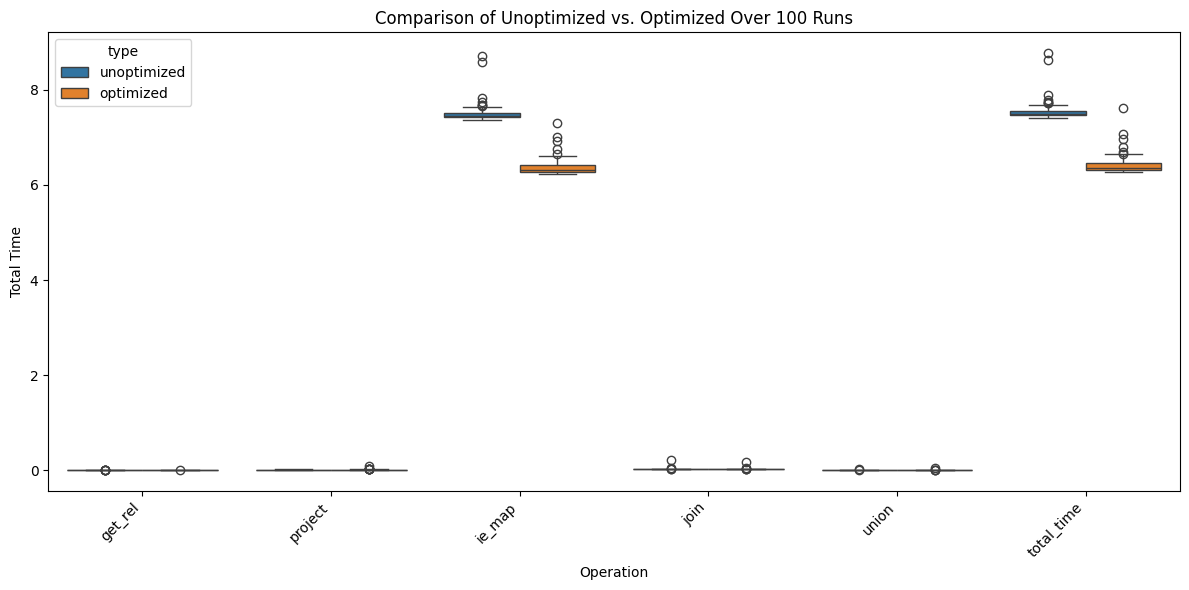

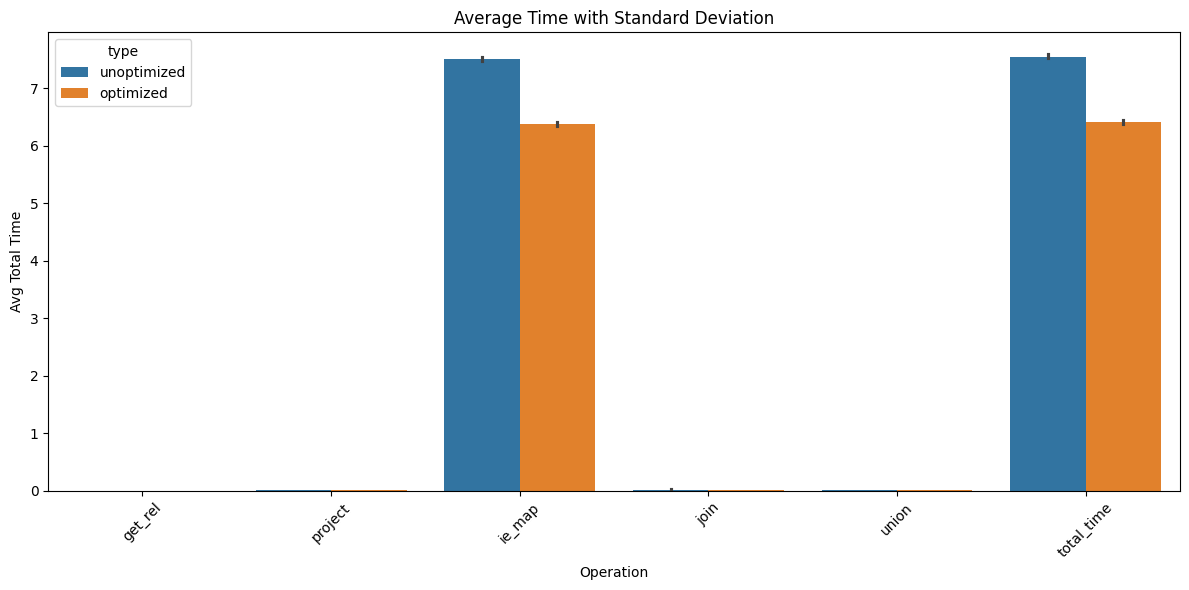

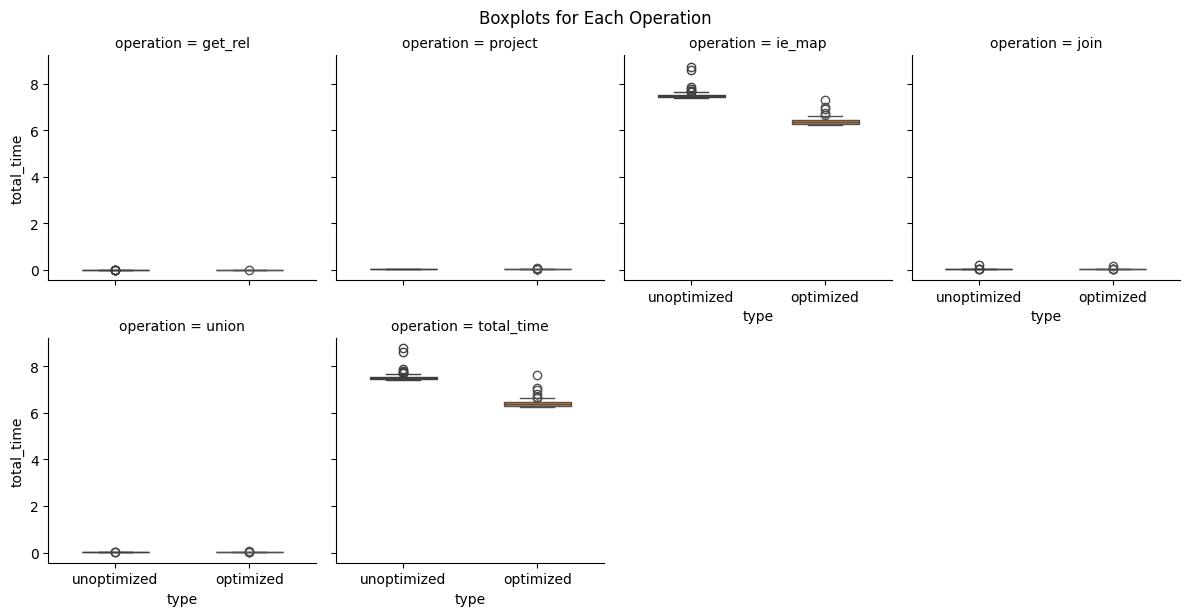

In [50]:
optimized_graph = profile_optimizations(optimized_graph, [], [optimize_with_sub_regex], benchmark=True)

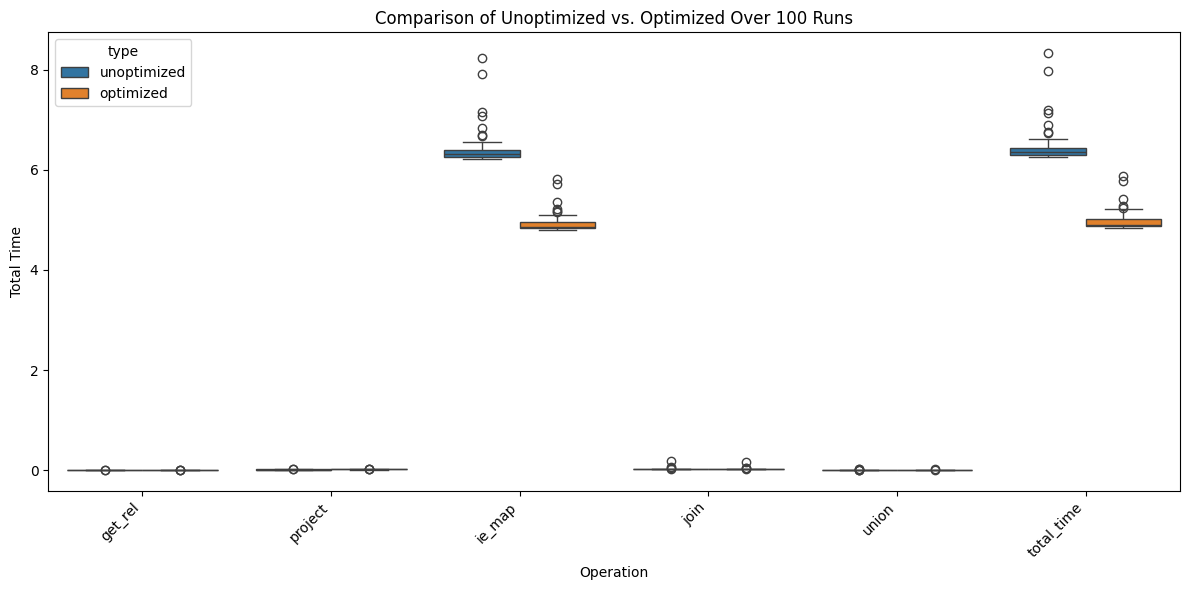

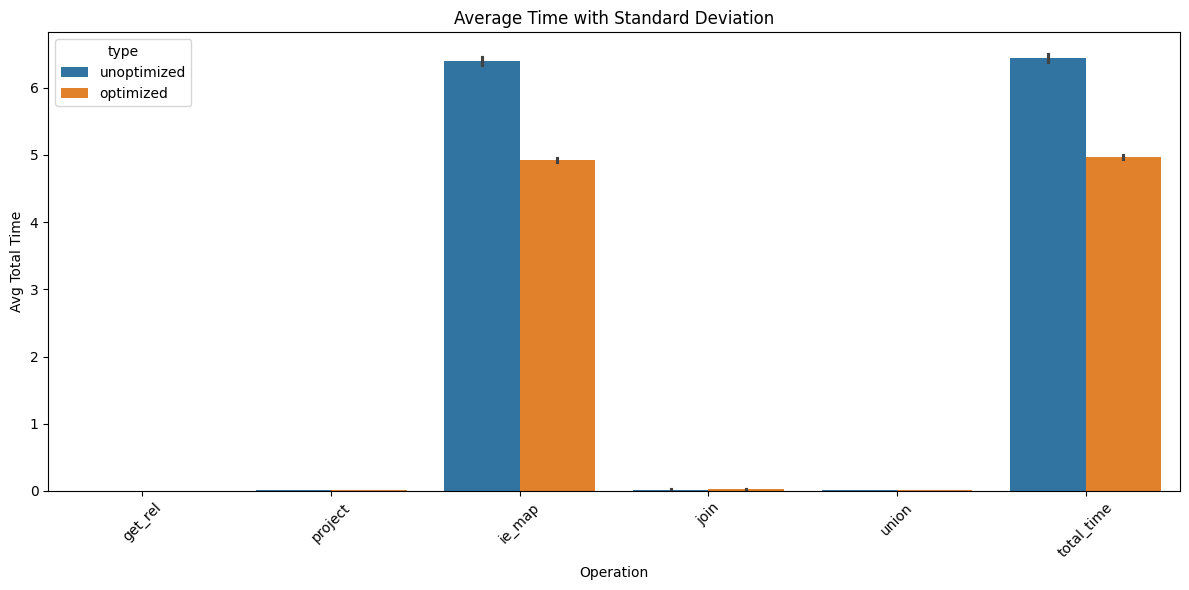

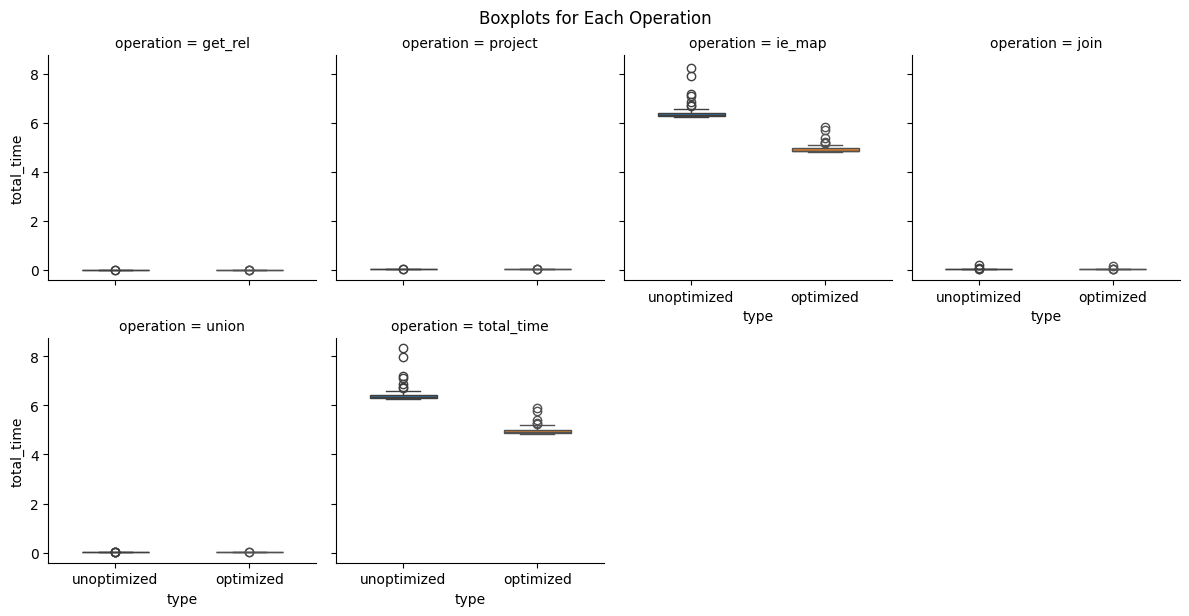

In [51]:
optimized_graph = profile_optimizations(optimized_graph, [], [close_location_optimization], benchmark=True)